#Using MNIST Handwritten Digits Data, we are going to create a Convolution Neural Network (CNN) based Multi-Class Classifier which can classify hand-written digits provided by the user into one of the class between 0-9

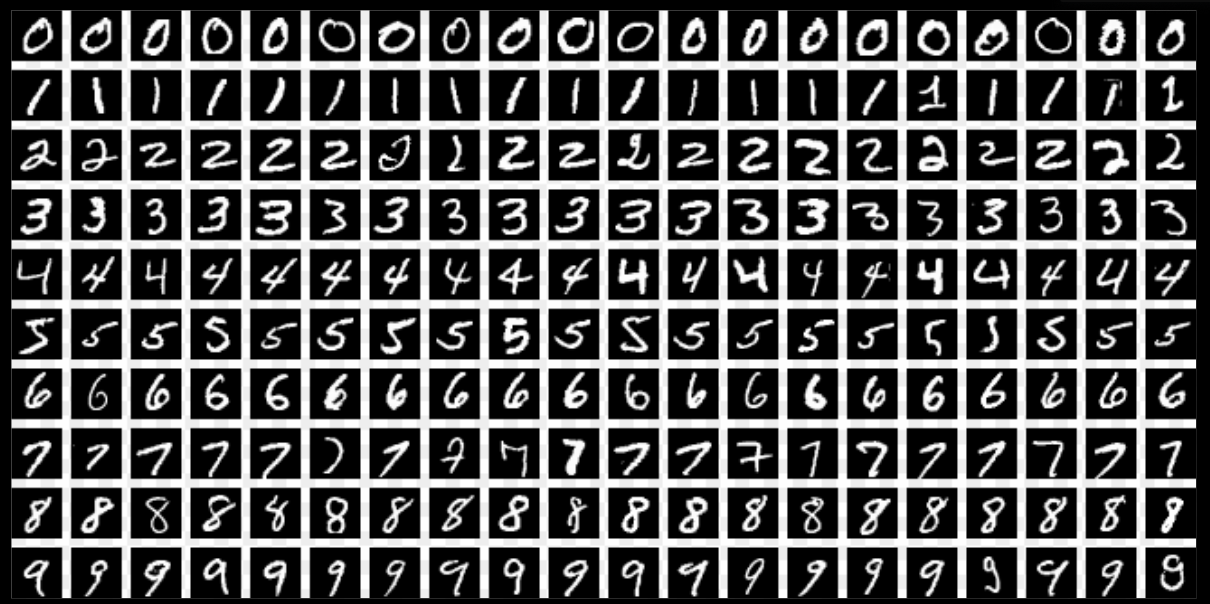

In [1]:
#importing necessary dependencies
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
from google.colab import files
from PIL import Image

In [3]:
#loading the MNIST dataset [MNIST data is already in greyscale but we still see the steps below to convert image into greyscale]
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#MNIST data comprises of 60,000 Training samples and 10,000 Testing samples
print("X Train shape:",x_train.shape)
print("Y Train shape:",y_train.shape)
print("X Test shape:",x_test.shape)
print("Y Test shape:",y_test.shape)

X Train shape: (60000, 28, 28)
Y Train shape: (60000,)
X Test shape: (10000, 28, 28)
Y Test shape: (10000,)


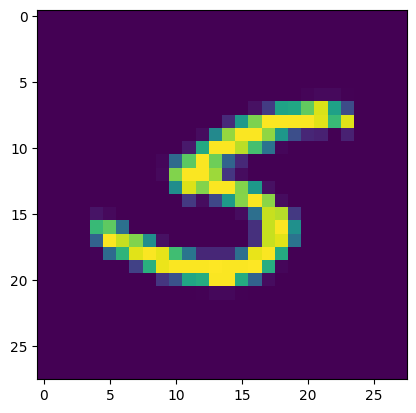

In [5]:
#Visualizing a sample image from MNIST data
plt.imshow(x_train[437]) #image at the 10th index position from x_train will be visualized

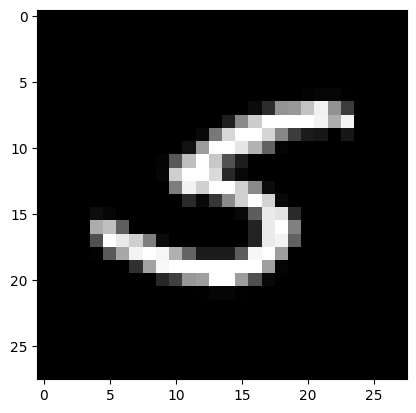

In [6]:
plt.imshow(x_train[437],cmap='gray')

In [7]:
sample_pixel=x_train[437]
print("Top left 5x5 pixel",sample_pixel[:5,:5])

Top left 5x5 pixel [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [8]:
#Pixels of input image
print("Pixel form of the overall image",sample_pixel[:,:])

Pixel form of the overall image [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   3   6   6   1   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  11  44
  148 152 194 241 146  59   0   0   0   0]
 [  0   0   0   0   0   0   0   

In [9]:
#Normalizing pixel values from [0-255] to [0-1]
x_train_norm=x_train.astype('float32')/255.0 #all the pixels from 60,000 images are getting normalized
x_test_norm=x_test.astype('float32')/255.0 #all the pixels from 10,000 images are getting normalized

In [10]:
x_train_norm.min() #minimum pixel value after normalization is 0

np.float32(0.0)

In [11]:
x_train_norm.max() #maximum pixel value after normalization is 1

np.float32(1.0)

In [12]:
sample_pixel=x_train_norm[238]
sample_pixel[:,:]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [13]:
#Performing Convolution operation followed by Pooling
one_image=x_train_norm[0:1] #the image size is 28x28

In [14]:
demo_conv=layers.Conv2D(filters=4,kernel_size=(3,3),activation="relu") #kernel size is 3x3
#the time taken to perform the convolution operation is going to be high but the accuracy will be optimal

Since the image is very large (28x28), supplying only 1 filter with size 3x3 will take us alot of time in performing the convolution operation [but the accuracy will be very high, just because the size of the filter is small]


So instead of 1 filter with size 3x3, we use 4 filters with size 3x3 to speed up the process while maintaining similar accuracy

In [15]:
#Performing Pooling on top of the Feature Map
demo_pool=layers.MaxPooling2D(pool_size=(2,2))

In [16]:
one_image = np.expand_dims(one_image, axis=-1)
conv_output=demo_conv(one_image) #conv_output is the Feature Map which will be passed to the Pooling layer

In [17]:
pool_output=demo_pool(conv_output) #Feature Map (conv_output) gets passed on to the pooling layer

In [18]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [19]:
pool_output.shape #because of the pooling window (2x2), the size becomes 26/2 = 13

TensorShape([1, 13, 13, 4])

- From 26x26 the size gets reduced to 13x13 after Pooling takes place [reduces the spacial size from 26 -> 13 but keeps the most important features]
- Since we are using 4 Filters in the Convolution layer, each filter will create one Feature Map meaning, 4 different feature maps detecting different patterns

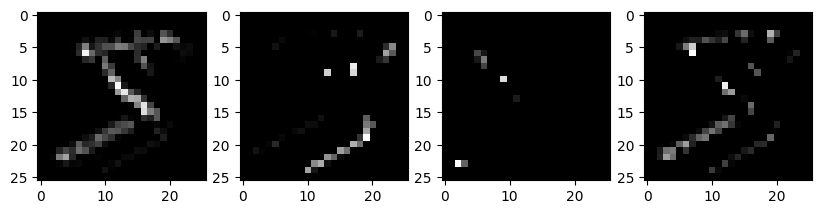

In [20]:
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(conv_output[0,:,:,i],cmap='grey')

plt.show() #we can see all the 4 feature maps at once

In [21]:
demo_flatten=layers.Flatten()
flatten_output=demo_flatten(pool_output)

In [22]:
pool_output.shape

TensorShape([1, 13, 13, 4])

In [23]:
flatten_output.shape # 13x13x4 = 676 [We have 4 Feature Maps]
#[X1,X2,X3,.....,X676] Long Vector will be passed to the NN

TensorShape([1, 676])

- Feature Map 1 - 13x13
- Feature Map 2 - 13x13
- Feature Map 3 - 13x13
- Feature Map 4 - 13x13


In [24]:
#Building the CNN Image Classifier
model=models.Sequential([
    layers.Input(shape=(28,28,1), #here 28x28 is the height and width of the input image with 1 channel
                 name='input_layer'),
    layers.Conv2D(16,(3,3),activation='relu',name='first_convolution_layer'), #16 filters, each of size 3x3. Each filter will produce one Feature Map
    layers.MaxPooling2D((2,2),name='first_pooling_layer'), #pool_size is 2x2
    layers.Conv2D(32,(3,3),activation='relu',name='second_convolution_layer'), #32 filters
    layers.MaxPooling2D((2,2),name='second_pooling_layer'),
    layers.Flatten(), #5x5x32=800 values (already processed so no need for additional processing using Activation Functions)
    layers.Dense(64,activation='relu',name='Hidden_Layer'),#64 neurons will be generated as output from 800 values
    layers.Dense(10,activation='softmax',name='Output_Layer')#10 neurons will be generated as output from 64 values
    #The model will predict 10 possible classes
    ])

In [25]:
#Compiling the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#Training the Model
epochs=10 #10 forward and 10 backward propagation
history=model.fit(x_train_norm,y_train,epochs=epochs,batch_size=128)
#since batch size is 128, it means 60000/128=469 batches per epoch

Epoch 1/10
235/469 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7398 - loss: 0.9341

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)
print("Test Accuracy:",test_accuracy)

Training Accuracy is 99.44% and Testing Accuracy is 98.875 which proves that the model is not Overfitting, it actually has learnt the patterns well and is rightly showcasing an accuracy of 99+%

Predictions on Custom Dataset